# Day 2: Absolute Magnitude Target

**Theme:** Convert cleaned Gaia measurements into the regression target for Week 2.

Today we will:

- load the cleaned Day 1 dataset
- compute distance in parsecs from Gaia parallax
- compute `abs_g_mag`, the absolute Gaia G magnitude target
- inspect summary statistics for the new target
- plot the target distribution
- build an HR-style color-magnitude diagram
- save the Day 2 target dataset for the next notebooks

Apparent magnitude tells us how bright a star looks from Earth. Absolute magnitude estimates how bright that star would look from a standard distance of 10 parsecs, so it is a distance-adjusted measure of intrinsic brightness. This makes `abs_g_mag` a useful target for regression.


## 1. Imports

Day 2 normally works from the local cleaned CSV created on Day 1. If that file is missing, the load cell can query Gaia DR3 and apply the same beginner-friendly cleaning rules used on Day 1.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


## 2. Load The Cleaned Gaia Data

The path candidates below let the notebook run whether the Jupyter kernel starts in `gaia-explorer/notebooks`, `gaia-explorer`, or the repository root. The notebook first tries the saved Day 1 CSV. If it is not present and `USE_GAIA_QUERY_IF_MISSING` is `True`, the shared loader queries Gaia DR3, cleans the returned rows, and saves the cleaned CSV for future reruns.


In [2]:
project_root_candidates = [Path(".."), Path("."), Path("gaia-explorer")]
PROJECT_ROOT = next((path for path in project_root_candidates if (path / "src").exists()), None)

if PROJECT_ROOT is None:
    searched = "\n".join(str(path.resolve()) for path in project_root_candidates)
    raise FileNotFoundError(f"Could not find gaia-explorer/src. Searched:\n{searched}")

sys.path.insert(0, str(PROJECT_ROOT.resolve()))

from src.data_load import load_clean_gaia_sample

input_candidates = [
    Path("../data/processed/gaia_clean_day1.csv"),
    Path("data/processed/gaia_clean_day1.csv"),
    Path("gaia-explorer/data/processed/gaia_clean_day1.csv"),
]

TOP_N = 10_000
USE_GAIA_QUERY_IF_MISSING = True
SNR_THRESHOLD = 5

gaia_df, DATA_PATH = load_clean_gaia_sample(
    input_candidates,
    top_n=TOP_N,
    use_query_if_missing=USE_GAIA_QUERY_IF_MISSING,
    snr_threshold=SNR_THRESHOLD,
)

print("Cleaned shape:", gaia_df.shape)
gaia_df.head()


Loaded cleaned Gaia data from: ../data/processed/gaia_clean_day1.csv
Cleaned shape: (2413, 8)


,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,parallax_snr
0,137338902210136064,45.039785,35.288983,0.952696,0.102076,17.505278,1.725426,9.333179
1,137341135593106176,45.141976,35.385239,0.816515,0.032551,15.057502,0.926100,25.084431
2,137342028946292224,45.154690,35.461248,2.357042,0.231949,18.740726,3.103573,10.161903
3,137345052603307136,44.952444,35.304778,1.039784,0.057366,16.250584,1.242174,18.125324
4,137346220834302080,44.944379,35.374441,1.371356,0.040912,15.746337,1.309051,33.519712


## 3. Confirm Required Columns

To create the target we need:

- `parallax`: Gaia parallax in milliarcseconds
- `phot_g_mean_mag`: apparent G-band magnitude
- `bp_rp`: color index for the color-magnitude diagram
- `parallax_snr`: Day 1 quality feature used for diagnostics


In [3]:
required_columns = [
    "parallax",
    "phot_g_mean_mag",
    "bp_rp",
    "parallax_snr",
]

missing_required_columns = [col for col in required_columns if col not in gaia_df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

if (gaia_df["parallax"] <= 0).any():
    raise ValueError("Day 2 requires positive parallax values. Re-run the Day 1 cleaning notebook.")

gaia_df[required_columns].head()


,parallax,phot_g_mean_mag,bp_rp,parallax_snr
0,0.952696,17.505278,1.725426,9.333179
1,0.816515,15.057502,0.926100,25.084431
2,2.357042,18.740726,3.103573,10.161903
3,1.039784,16.250584,1.242174,18.125324
4,1.371356,15.746337,1.309051,33.519712


## 4. Compute Distance And Absolute Magnitude

Gaia parallax is measured in milliarcseconds, so distance in parsecs is:

$$
\text{distance\_pc} = \frac{1000}{\text{parallax}}
$$

The absolute Gaia G magnitude target is:

$$
\text{abs\_g\_mag} = \text{phot\_g\_mean\_mag} + 5 \log_{10}(\text{parallax}) - 10
$$

This is equivalent to the distance-modulus form `M = m - 5 * log10(distance_pc / 10)`.


In [4]:
target_df = gaia_df.copy()

# Parallax is in milliarcseconds, so 1000 / parallax gives distance in parsecs.
target_df["distance_pc"] = 1000 / target_df["parallax"]

# Store the regression target requested by the Day 2 spec.
# Absolute magnitude uses the distance modulus: M = m - 5 * log10(d / 10).
# Since Gaia parallax is in milliarcseconds, d = 1000 / parallax.
# Substituting that distance into the distance modulus simplifies to:
# M = m + 5 * log10(parallax) - 10.
target_df["abs_g_mag"] = target_df["phot_g_mean_mag"] + 5 * np.log10(target_df["parallax"]) - 10

# This is the same formula written in the original distance-modulus form.
abs_g_mag_from_distance = target_df["phot_g_mean_mag"] - 5 * np.log10(target_df["distance_pc"] / 10)

# np.allclose allows tiny floating-point rounding differences.
print("Formula check matches distance-modulus form:", np.allclose(target_df["abs_g_mag"], abs_g_mag_from_distance))

target_df[["source_id", "parallax", "distance_pc", "phot_g_mean_mag", "abs_g_mag", "bp_rp"]].head()


Formula check matches distance-modulus form: True


,source_id,parallax,distance_pc,phot_g_mean_mag,abs_g_mag,bp_rp
0,137338902210136064,0.952696,1049.652247,17.505278,7.400051,1.725426
1,137341135593106176,0.816515,1224.716602,15.057502,4.617324,0.926100
2,137342028946292224,2.357042,424.260559,18.740726,10.602563,3.103573
3,137345052603307136,1.039784,961.738436,16.250584,6.335299,1.242174
4,137346220834302080,1.371356,729.205222,15.746337,6.432088,1.309051


## 5. Target Summary Statistics

These summary statistics check whether distances and absolute magnitudes are in a plausible range before we train models on them.


In [5]:
target_summary = target_df[["distance_pc", "abs_g_mag"]].describe().T
target_summary


,count,mean,std,min,25%,50%,75%,max
distance_pc,2413.0,1234.867483,905.049817,31.316839,604.977844,1037.715042,1595.823610,9415.134615
abs_g_mag,2413.0,6.296961,2.659164,-2.222447,4.504138,5.956095,8.003989,14.982124


## 6. Histogram Of Absolute G Magnitude

Magnitude is inverted: smaller values mean brighter stars. A histogram helps show the target range the regression model will need to learn.


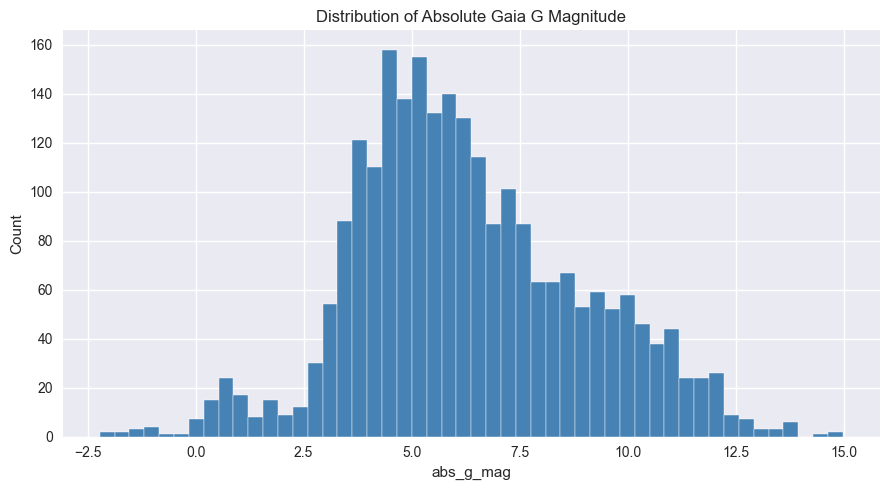

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(target_df["abs_g_mag"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Absolute Gaia G Magnitude")
ax.set_xlabel("abs_g_mag")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 7. HR-Style Color-Magnitude Diagram

A color-magnitude diagram places color on the x-axis and absolute magnitude on the y-axis. Astronomers usually invert the magnitude axis so brighter stars appear higher on the plot.


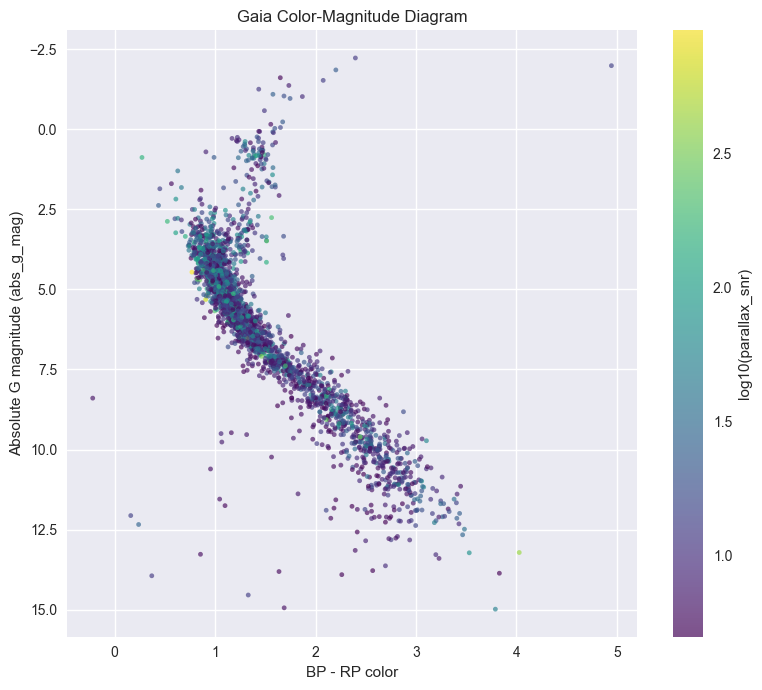

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    target_df["bp_rp"],
    target_df["abs_g_mag"],
    c=np.log10(target_df["parallax_snr"]),
    cmap="viridis",
    s=12,
    alpha=0.65,
    linewidths=0,
)

ax.invert_yaxis()
ax.set_title("Gaia Color-Magnitude Diagram")
ax.set_xlabel("BP - RP color")
ax.set_ylabel("Absolute G magnitude (abs_g_mag)")

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("log10(parallax_snr)")

plt.tight_layout()
plt.show()


## 8. Interpret The Color-Magnitude Diagram

Each dot is one Gaia star.

- `BP - RP color` on the x-axis is a rough temperature clue. Smaller values are bluer and hotter; larger values are redder and cooler.
- `abs_g_mag` on the y-axis is intrinsic brightness. The axis is inverted, so brighter stars with smaller magnitude values appear higher.
- The dot color shows `log10(parallax_snr)`, which is the reliability of the parallax measurement. Higher values mean the distance and absolute magnitude are more trustworthy.

Look for a diagonal band from upper-left toward lower-right. That band is the main sequence: hot bright stars on the upper-left side and cool faint stars on the lower-right side.

Other regions can also be meaningful:

- Upper-right: red but bright stars, often giant candidates.
- Lower-left: blue or white but faint stars, often white dwarf candidates.
- Bottom-right: cool faint stars, often red dwarf candidates.

This plot is useful because it shows that color and intrinsic brightness are physically connected. That is why `bp_rp` will be an important feature when we start regression.


## 9. Inspect Bright And Faint Examples

Because lower magnitude means brighter, the smallest `abs_g_mag` values are the intrinsically brightest stars in this cleaned sample.


In [8]:
example_columns = [
    "source_id",
    "bp_rp",
    "parallax",
    "distance_pc",
    "phot_g_mean_mag",
    "abs_g_mag",
    "parallax_snr",
]

bright_examples = target_df.nsmallest(5, "abs_g_mag")[example_columns]
faint_examples = target_df.nlargest(5, "abs_g_mag")[example_columns]

pd.concat(
    {
        "brightest_by_abs_g_mag": bright_examples,
        "faintest_by_abs_g_mag": faint_examples,
    },
    names=["group", "row"],
)


source_id     bp_rp   parallax  \
group                  row                                             
brightest_by_abs_g_mag 646   139505421154164096  2.396215   0.294768   
                       2181  138831454885582336  4.945676   1.076976   
                       1971  139487176133134848  2.201745   0.514684   
                       415   139189002322968960  1.648611   0.106212   
                       538   139370284302756224  2.075794   0.286648   
faintest_by_abs_g_mag  1996  138857843163156736  3.790125  15.553052   
                       1353  138834439886695552  1.687286   8.813850   
                       242   139152782863115776  1.329372  13.590845   
                       337   138986790966819200  0.368959   6.328742   
                       689   139539948395575040  2.260855   4.970859   

                             distance_pc  phot_g_mean_mag  abs_g_mag  \
group                  row                                             
brightest_by_abs_g_mag 646   3392.494096        10.430149  -2.222447   
                       2181   928.525808         7.856598  -1.982372   
                       1971  1942.940935         9.593148  -1.849150   
                       415   9415.134615        13.263099  -1.606034   
                       538   3488.594005        11.189521  -1.523731   
faintest_by_abs_g_mag  1996    64.296060        19.023046  14.982124   
                       1353   113.457795        20.214655  14.940483   
                       242     73.578945        18.874445  14.540677   
                       337    158.009275        19.933514  13.940101   
                       689    201.172460        20.422848  13.905005   

                             parallax_snr  
group                  row                 
brightest_by_abs_g_mag 646      12.158059  
                       2181     13.291227  
                       1971     22.052383  
                       415       5.246638  
                       538      12.529866  
faintest_by_abs_g_mag  1996     47.377927  
                       1353      6.250822  
                       242      12.883895  
                       337      12.149565  
                       689       5.290931

## 10. Save The Day 2 Target Dataset

The next notebooks can load this file directly instead of recomputing the target each time.


In [9]:
output_candidates = [
    Path("../data/processed/gaia_day2_absolute_magnitude.csv"),
    Path("data/processed/gaia_day2_absolute_magnitude.csv"),
    Path("gaia-explorer/data/processed/gaia_day2_absolute_magnitude.csv"),
]

OUTPUT_PATH = next((path for path in output_candidates if path.parent.exists()), output_candidates[0])
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

target_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved Day 2 target data to: {OUTPUT_PATH}")
print("Saved shape:", target_df.shape)
print("New columns:", ["distance_pc", "abs_g_mag"])


Saved Day 2 target data to: ../data/processed/gaia_day2_absolute_magnitude.csv
Saved shape: (2413, 10)
New columns: ['distance_pc', 'abs_g_mag']


## Reflection Questions And Answers

1. What does absolute magnitude measure that apparent magnitude does not?

   **Answer:** Absolute magnitude estimates a star's intrinsic brightness by correcting for distance. Apparent magnitude only tells us how bright the star looks from Earth, so a faraway bright star can look dim and a nearby dim star can look bright.

2. Why do astronomers invert the y-axis for magnitude plots?

   **Answer:** The magnitude scale is backwards: smaller magnitude values mean brighter stars. Inverting the y-axis puts brighter stars higher on the diagram, which matches the standard HR diagram style.

3. Is the main sequence visible in the color-magnitude diagram? What pattern do you see?

   **Answer:** A main-sequence-like diagonal band should be visible if the sample has enough stars. It usually runs from hot, bright stars on the upper-left toward cool, faint stars on the lower-right.

4. Which stars in this sample are intrinsically brightest: the smallest or largest `abs_g_mag` values?

   **Answer:** The smallest `abs_g_mag` values are intrinsically brightest because lower magnitude means higher brightness.

5. Why would noisy or near-zero parallax make `distance_pc` and `abs_g_mag` unreliable?

   **Answer:** Distance is calculated as `distance_pc = 1000 / parallax`, so very small parallax values create very large distances. If the parallax measurement is noisy, that error gets amplified in both distance and absolute magnitude. This is why we filter with `parallax_snr > 5`.
